In [27]:
from starter_kit.load_utility import *
from starter_kit.data_loader import *
from starter_kit.model import *
from starter_kit.submission import *
import torch
import torch.nn as nn
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

In [28]:
class InceptionMid(nn.Module):
    def __init__(self, num_blocks):
        super().__init__()
        base = load_base_inception("starter_kit/inception_v3.pth")
        self.backbone = nn.Sequential(*list(base.children())[:num_blocks]).eval()
        self.transform = load_inception_transforms()

    def forward(self, x: torch.Tensor):
        return self.backbone(self.transform(x))

In [29]:
device = torch.device("mps")

inception = InceptionMid(num_blocks=13).to(device=device)

In [30]:
X, y = load_data("problem_data/", task="subtask1", split="unordered")

In [31]:
decoder = load_decoder(path="starter_kit/decoder.pt", device="mps")

In [32]:
X.shape

torch.Size([1500, 128])

In [33]:
y.shape

torch.Size([1500, 3, 160, 160])

In [34]:
import tqdm


In [35]:
import torch

all_decoded = []

decoder.eval()

for i in tqdm.tqdm(range(0, len(X), 10)):
  with torch.no_grad():
    dec = decoder(X[i:i + 10].to(device=device)).detach().cpu().numpy()
  all_decoded.append(dec)

100%|██████████| 150/150 [00:11<00:00, 13.42it/s]


In [36]:
import numpy as np

all_decoded = torch.Tensor(np.array(all_decoded)).reshape(1500, 3, 160, 160)

In [37]:
all_decoded[-1].shape

torch.Size([3, 160, 160])

In [38]:
all_decoded.shape

torch.Size([1500, 3, 160, 160])

In [39]:
X_inception = []
y_inception = []

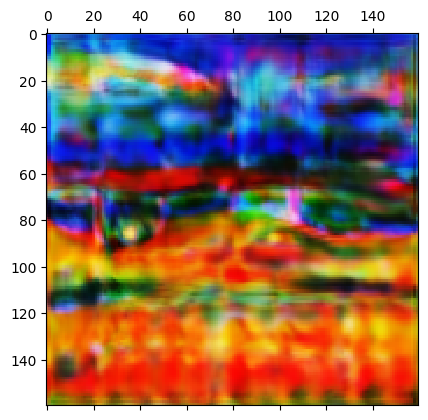

In [40]:
import matplotlib.pyplot as plt

plt.matshow(all_decoded[7].permute(1, 2, 0))

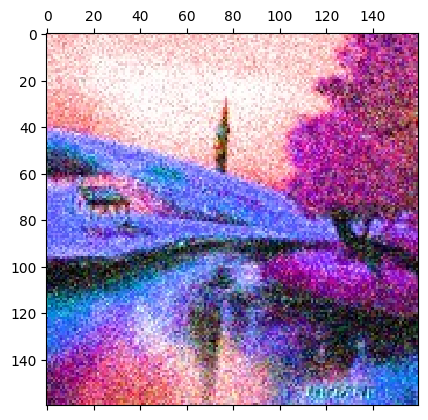

In [41]:
plt.matshow(y[10].permute(1, 2, 0))

In [42]:
inception = inception.to(device=device)

for i in tqdm.tqdm(range(0, len(all_decoded), 10)):
  inception_X = inception(all_decoded[i:i + 10].to(device=device))
  X_inception.append(inception_X.detach().cpu().numpy())

100%|██████████| 150/150 [00:07<00:00, 19.62it/s]


In [43]:
for i in tqdm.tqdm(range(0, len(y), 10)):
  inception_y = inception(y[i:i + 10].to(device=device))
  y_inception.append(inception_y.detach().cpu().numpy())

100%|██████████| 150/150 [00:06<00:00, 22.30it/s]


In [44]:
X_inception = torch.Tensor(X_inception)
y_inception = torch.Tensor(y_inception)

/var/folders/rc/zj7g12rj7r949pfg4d2kq1nh0000gn/T/ipykernel_24265/2896674389.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  X_inception = torch.Tensor(X_inception)


In [45]:
X_inception = X_inception.reshape(1500, -1)

In [46]:
y_inception = y_inception.reshape(1500, -1)

In [47]:
all_decoded.shape

torch.Size([1500, 3, 160, 160])

In [48]:
X_inception.shape

torch.Size([1500, 221952])

In [49]:
from sklearn.metrics.pairwise import cosine_distances

sims = cosine_distances(X_inception, y_inception)

In [50]:
from scipy.optimize import linear_sum_assignment
row_ind, col_ind = linear_sum_assignment(sims)

In [51]:
row_ind

array([   0,    1,    2, ..., 1497, 1498, 1499])

In [52]:
sims

array([[0.6248405 , 0.65848595, 0.6292535 , ..., 0.6350225 , 0.62216294,
        0.6194134 ],
       [0.6018094 , 0.62447035, 0.63676584, ..., 0.6181392 , 0.6160632 ,
        0.6363219 ],
       [0.59735435, 0.62488097, 0.61409986, ..., 0.60490793, 0.5974233 ,
        0.62369335],
       ...,
       [0.6122345 , 0.62783754, 0.6200843 , ..., 0.61910343, 0.63478935,
        0.6193281 ],
       [0.5978806 , 0.6298595 , 0.62165225, ..., 0.6183668 , 0.61877286,
        0.63433564],
       [0.6146533 , 0.6457323 , 0.6257032 , ..., 0.61474854, 0.6264441 ,
        0.64230144]], dtype=float32)

In [53]:
ans_task1 = submit_task1(col_ind)

In [54]:
ans_task1

,subtaskID,datapointID,answer
0,1,0,766
1,1,1,632
2,1,2,1007
3,1,3,984
4,1,4,7
...,...,...,...
1495,1,1495,730
1496,1,1496,722
1497,1,1497,963
1498,1,1498,962


In [55]:
ans_task1.to_csv("sub.csv", index=False)

In [56]:
X2, y2 = load_data("problem_data/", task="subtask2", split="train")

In [57]:
X2.shape

torch.Size([4000, 128])

In [58]:
y2.shape

torch.Size([4000, 3, 160, 160])

In [59]:
loss_fn = nn.MSELoss()
opt = torch.optim.Adam(decoder.parameters())

def train_e(e):
  print("Epoch: ", e)
  loss_run = 0
  for i in tqdm.tqdm(range(0, len(X2), 16)):
    X = X2[i:i + 16].to(device=device)
    y = y2[i:i + 16].to(device=device)

    output = decoder(X)

    feat_output = inception(output)
    feat_y = inception(y)

    loss = loss_fn(feat_output, feat_y)
    loss_run += loss.item()
    opt.zero_grad()
    loss.backward()
    opt.step()

  print(loss_run)

In [ ]:
for i in range(10): train_e(i)

In [61]:
X2_test, y2_test = load_data("problem_data/", task="subtask2", split="test")

In [62]:
X2_test.shape

torch.Size([500, 128])

In [74]:
dec_sb2 = []

for i in tqdm.tqdm(range(0, len(X2_test), 10)):
    with torch.no_grad():
        dec = decoder(X2_test[i:i+10].to(device=device))
        dec_sb2.append(dec.detach().cpu().numpy())

100%|██████████| 50/50 [00:04<00:00, 11.78it/s]


In [75]:
dec_sb2 = np.array(dec_sb2)

In [76]:
dec_sb2_np = dec_sb2.reshape(-1, 3, 160, 160).transpose(0, 2, 3, 1)

In [77]:
dec_sb2_np.shape

(500, 160, 160, 3)

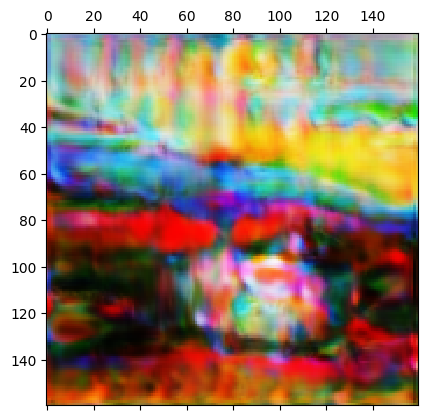

In [78]:
import matplotlib.pyplot as plt

plt.matshow(dec_sb2_np[32])

In [80]:
dec_sb2.shape

(50, 10, 3, 160, 160)

In [84]:
feat_incep = []

for batch in tqdm.tqdm(dec_sb2):
    incpt_feat = inception(torch.Tensor(batch).to(device=device))
    feat_incep.append(incpt_feat.detach().cpu().numpy())

100%|██████████| 50/50 [00:02<00:00, 19.80it/s]


In [85]:
feat_incep = np.array(feat_incep)

In [87]:
feat_incep = feat_incep.reshape(-1, 768, 17, 17)

In [88]:
feat_incep.shape

(500, 768, 17, 17)

In [89]:
ans_task2 = submit_task2(feat_incep)

In [92]:
ans_task2.to_csv("ans2.csv", index=False)